# 1. Benchmark of force-indentation frameworks

In this notebook, we compare the performance of ForceIndent-JAX with ViscoIndent, which, to our knowledge, is the only other framework currently able to numerically simulate force-indentation data for a wide variety of constitutive models.

In [1]:
%run _common.ipynb
%matplotlib inline
import time

import jax
import jax.numpy as jnp
from jaxtyping import Float, Array
import numpy as np
import equinox as eqx
import matplotlib.pyplot as plt
from tqdm import tqdm

from neuralconstitutive.indentation import (
    ConstantVelocity,
    CubicSpline,
    IndentationBuilder,
    AbstractIndentation
)
from neuralconstitutive.tipgeometry import AbstractTipGeometry, Spherical, Conical
from neuralconstitutive.constitutive import AbstractConstitutive, Hertzian, PowerLaw
from neuralconstitutive.ting.numerical import force_ting
from neuralconstitutive.ting.analytic import force_powerlaw
from neuralconstitutive.utils.metrics import NMSE, SMAPE
from neuralconstitutive.plotting import MM, ordered_legend, connected_scatter, draw_triangle
from ViscoIndent.Ting_numerical import ting_numerical

## ForceIndent-JAX

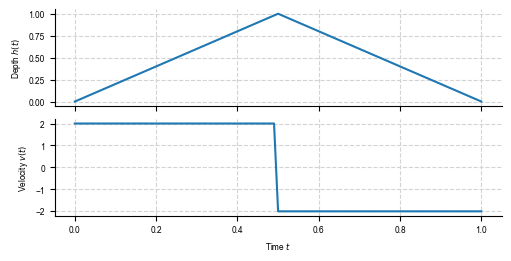

In [2]:
tip = Spherical(r=1.0)
indentation = (
    IndentationBuilder()
    .append(ConstantVelocity(velocity_=2.0), duration=0.5)
    .append(ConstantVelocity(velocity_=-2.0), duration=0.5)
    .build()
)
dt = 1e-2
t = jnp.arange(0.0, 1.0 + dt, dt)
h_t = jax.vmap(indentation.depth)(t)
v_t = jax.vmap(indentation.velocity)(t)

# Inspect the resulting indentation
fig, axes = plt.subplots(2, 1, figsize=(5, 2.5), sharex=True)
ylabels = ("Depth $h(t)$", "Velocity $v(t)$")
for ax, y, ylabel in zip(axes, (h_t, v_t), ylabels):
    ax.plot(t, y)
    ax.set_ylabel(ylabel)
axes[1].set_xlabel("Time $t$")

powerlaw = PowerLaw(E0=3.0, alpha=0.2)

In [3]:
f_powerlaw = eqx.filter_jit(force_ting)(
    t, powerlaw, indentation, tip
).block_until_ready()

## ViscoIndent

Before our experiment, we define some utility functions

In [4]:
def tipgeometry_to_viscoindent_args(tip: AbstractTipGeometry) -> tuple[str, float]:
    match tip:
        case Spherical(r=r_):
            modelprobe = "sphere"
            probe_size = r_
        case Conical(theta=theta_):
            modelprobe = "cone"
            probe_size = theta_ * 180 / jnp.pi
        case _:
            raise ValueError("Unsupported tip shape!")
    return modelprobe, float(probe_size)


def constitutive_to_viscoindent_args(
    constit: AbstractConstitutive,
) -> tuple[str, list[float]]:
    match constit:
        case Hertzian(E0=E0_):
            modelting = "elastic"
            model_params = [E0_]
        case PowerLaw(E0=E0_, alpha=alpha_):
            modelting = "springpot"
            model_params = [E0_, alpha_]
        case _:
            raise ValueError("Unsupported constitutive equation!")
    model_params = list(map(float, model_params))
    return modelting, model_params


def force_viscoindent(
    time: Float[Array, " N"],
    constit: AbstractConstitutive,
    indentation: AbstractIndentation | Float[Array, " N"],
    tip: AbstractTipGeometry,
) -> Float[Array, " N"]:
    modelting, model_params = constitutive_to_viscoindent_args(constit)
    modelprobe, probe_size = tipgeometry_to_viscoindent_args(tip)
    dt = float(time[1] - time[0])
    max_ind = int(jnp.argmin(jnp.abs(time - indentation.t_ret)))
    depth_array = np.asarray(jax.vmap(indentation.depth)(time))

    force, *_ = ting_numerical(
        model_params,
        None,
        0.5,
        probe_size,
        dt,
        max_ind,
        0,
        modelting,
        modelprobe,
        depth_array,
    )
    return force

We also define a function (and associated helper functions) to calculate the analytical solution for the force, again with the same signature as `force_ting` and `force_viscoindent` functions

In [5]:
f_viscoindent = force_viscoindent(t, powerlaw, indentation, tip)

In [6]:
f_analytic = force_powerlaw(t, powerlaw, indentation, tip)

2024-09-07 18:42:19.270967: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


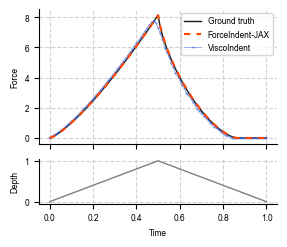

In [7]:
fig, axes = plt.subplots(
    2, 1, figsize=(70 * MM, 60 * MM), sharex=True, height_ratios=[3, 1]
)
ax = axes[0]

ax.plot(t, f_analytic, "k", linewidth=1.0, alpha=0.9, label="Ground truth")
# ax.scatter(t[::2], f_powerlaw[::2], s=10, facecolors=mplcolors.to_rgba(('w', 0.5)), edgecolors= "orangered", label="ForceIndent-JAX")
ax.plot(
    t,
    f_viscoindent,
    ".-",
    linewidth=0.5,
    color="royalblue",
    alpha=0.75,
    label="ViscoIndent",
)
ax.plot(
    t,
    f_powerlaw,
    "--",
    linewidth=1.5,
    dashes=(3, 3),
    color="orangered",
    label="ForceIndent-JAX",
)
ax = ordered_legend(ax, [0, 2, 1])
ax.set_ylabel("Force")

ax = axes[1]
ax.plot(t, h_t, color="gray", linewidth=1.0)
ax.set_ylabel("Depth")
ax.set_xlabel("Time")

fig.savefig("../figures/fig2-a.pdf", format="pdf", dpi=1200)

In [8]:
tip = Spherical(r=1.0)
indentation = (
    IndentationBuilder()
    .append(ConstantVelocity(velocity_=2.0), duration=0.5)
    .append(ConstantVelocity(velocity_=-2.0), duration=0.5)
    .build()
)
powerlaw = PowerLaw(E0=3.0, alpha=0.2)
err_func = SMAPE

dt_list = [1e-4, 2e-4, 5e-4, 1e-3, 2e-3, 5e-3, 1e-2]
exp_dict = {k: {"Viscoindent": [], "ForceIndent-JAX": []} for k in ("dt", "alpha")}

force_ting_jit = eqx.filter_jit(force_ting)

for dt in tqdm(dt_list):
    t = jnp.arange(0.0, 1.0 + dt, dt)
    f_ting = force_ting_jit(t, powerlaw, indentation, tip)
    f_visco = force_viscoindent(t, powerlaw, indentation, tip)
    f_true = force_powerlaw(t, powerlaw, indentation, tip)
    exp_dict["dt"]["ForceIndent-JAX"].append(err_func(f_ting, f_true))
    exp_dict["dt"]["Viscoindent"].append(err_func(f_visco, f_true))

## Singularity strength experiment
dt = 1e-3
t = jnp.arange(0.0, 1.0 + dt, dt)

force_ting_jit = eqx.filter_jit(force_ting)
for alpha_ in tqdm(alpha_array := jnp.arange(0.0, 1.0, 0.1)):
    powerlaw = PowerLaw(E0=3.0, alpha=alpha_)
    f_ting = force_ting_jit(t, powerlaw, indentation, tip)
    f_visco = force_viscoindent(t, powerlaw, indentation, tip)
    f_true = force_powerlaw(t, powerlaw, indentation, tip)
    exp_dict["alpha"]["ForceIndent-JAX"].append(err_func(f_ting, f_true))
    exp_dict["alpha"]["Viscoindent"].append(err_func(f_visco, f_true))

100%|██████████| 10/10 [00:01<00:00,  5.83it/s]


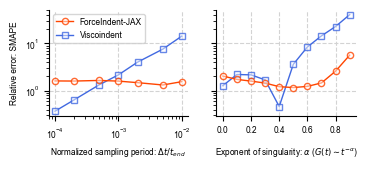

In [76]:
fig, axes = plt.subplots(
    1, 2, figsize=(90 * MM, 40 * MM), sharey=True, gridspec_kw=dict(wspace=3 * MM)
)
dt_array = jnp.asarray(dt_list)

connected_scatter_kwargs = {
    "Viscoindent": dict(
        color="royalblue",
        marker="s",
        markersize=4,
        linealpha=0.8,
    ),
    "ForceIndent-JAX": dict(
        color="orangered",
        marker="o",
        markersize=4.5,
        linealpha=0.8,
    ),
}

ax = axes[0]
for name, y_data in exp_dict["dt"].items():
    ax = connected_scatter(
        ax, dt_array, y_data, label=name, **connected_scatter_kwargs[name]
    )

ax.set_xscale("log", base=10)
ax.set_yscale("log", base=10)
ax = ordered_legend(ax, [1, 0])
ax.set_xlabel(r"Normalized sampling period: $\Delta t/t_{end}$")
ax.set_ylabel("Relative error: SMAPE")

ax = axes[1]
for name, y_data in exp_dict["alpha"].items():
    ax = connected_scatter(
        ax, alpha_array, y_data, label=name, **connected_scatter_kwargs[name]
    )

ax.set_xlabel(r"Exponent of singularity: $\alpha$ ($G(t)\sim t^{-\alpha}$)")
ax.set_yscale("log", base=10)
fig.align_xlabels()
fig.savefig("../figures/fig2-bc.pdf", format="pdf", dpi=1200)

In [10]:
## TODO: figure out the cause of runtimewarnings from Viscoindent
tip = Spherical(r=1.0)
indentation = (
    IndentationBuilder()
    .append(ConstantVelocity(velocity_=2.0), duration=0.5)
    .append(ConstantVelocity(velocity_=-2.0), duration=0.5)
    .build()
)
powerlaw = PowerLaw(E0=3.0, alpha=0.2)
err_func = NMSE
dt = 1e-3
t = jnp.arange(0.0, 1.0 + dt, dt)
depth_true = jax.vmap(indentation.depth)(t)

noise_array = (
    jnp.asarray([0.0, 1e-3, 2e-3, 5e-3, 1e-2, 2e-2, 5e-2, 1e-1, 2e-1, 5e-1]) * 0.01
)
err_dict = {"ForceIndent-JAX": [], "Viscoindent": []}

force_ting_jit = eqx.filter_jit(force_ting)
rng_key = jax.random.PRNGKey(0)
unit_noise = jax.random.normal(rng_key, depth_true.shape)

f_true = force_powerlaw(t, powerlaw, indentation, tip)
is_app, is_ret = t <= indentation.t_ret, t >= indentation.t_ret

for noise_scale in tqdm(noise_array):
    depth_meas = depth_true + noise_scale * unit_noise
    indentation_visco = (
        IndentationBuilder(enforce_continuity=False)
        .append(CubicSpline(t[is_app], depth_meas[is_app], smoothing=0), duration=0.5)
        .append(CubicSpline(t[is_ret], depth_meas[is_ret], smoothing=0), duration=0.5)
        .build()
    )
    indentation_forceindent = (
        IndentationBuilder(enforce_continuity=False)
        .append(CubicSpline(t[is_app], depth_meas[is_app]), duration=0.5)
        .append(CubicSpline(t[is_ret], depth_meas[is_ret]), duration=0.5)
        .build()
    )
    # plt.plot(t, indentation_forceindent.velocity(t))
    f_visco = force_viscoindent(t, powerlaw, indentation_visco, tip)
    f_ting = force_ting_jit(t, powerlaw, indentation_forceindent, tip)
    plt.plot(t, f_visco)
    err_dict["ForceIndent-JAX"].append(err_func(f_ting, f_true))
    err_dict["Viscoindent"].append(err_func(f_visco, f_true))

  0%|          | 0/10 [00:00<?, ?it/s]/home/jhko725/Projects/NeuralConstitutiveEq.jl/notebooks/../ViscoIndent/Ting_numerical.py:85: RuntimeWarning: invalid value encountered in power
  ind2speed = np.diff(indentationfull**power) / dT
/home/jhko725/Projects/NeuralConstitutiveEq.jl/notebooks/../ViscoIndent/Ting_numerical.py:114: RuntimeWarning: invalid value encountered in sqrt
  cntrad = K12 * indentationfull ** (power - 1)  # contact probe_size
  0%|          | 0/10 [00:02<?, ?it/s]


KeyboardInterrupt: 

Text(0, 0.5, 'Normalized error (%)')

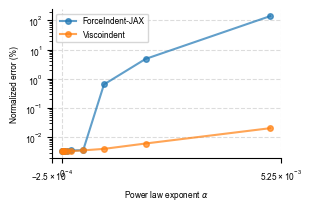

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2))

for k, v in err_dict.items():
    ax.plot(noise_array, jnp.asarray(v), ".-", markersize=8.0, label=k, alpha=0.7)
    ax.set_xscale("symlog", base=10)
    ax.set_yscale("log", base=10)
ax.legend()
ax.set_xlabel(r"Power law exponent $\alpha$")
ax.set_ylabel("Normalized error (%)")

In [11]:
def time_viscoindent(
    t: Float[Array, " N"],
    constit: AbstractConstitutive,
    indentation: AbstractIndentation | Float[Array, " N"],
    tip: AbstractTipGeometry,
) -> Float[Array, " N"]:
    modelting, model_params = constitutive_to_viscoindent_args(constit)
    modelprobe, probe_size = tipgeometry_to_viscoindent_args(tip)
    dt = float(t[1] - t[0])
    max_ind = int(jnp.argmin(jnp.abs(t - indentation.t_ret)))
    depth_array = np.asarray(jax.vmap(indentation.depth)(t))

    time_list = []
    for _ in range(10):
        t_start = time.time()
        _, *_ = ting_numerical(
            model_params,
            None,
            0.5,
            probe_size,
            dt,
            max_ind,
            0,
            modelting,
            modelprobe,
            depth_array,
        )
        dt = time.time() - t_start
        time_list.append(dt)
    return np.mean(time_list), np.std(time_list)

In [12]:
time_viscoindent(t, powerlaw, indentation, tip)

(0.021277737617492676, 0.0016410923266079553)

In [13]:
def time_forceindentjax(t, powerlaw, indentation, tip):
    force_ting_jit = eqx.filter_jit(force_ting)
    _ = force_ting_jit(
        t, powerlaw, indentation, tip
    ).block_until_ready()  # Initial untimed run for JIT compilation

    time_list = []
    for _ in range(10):
        t_start = time.time()
        _ = force_ting_jit(t, powerlaw, indentation, tip).block_until_ready()
        dt = time.time() - t_start
        time_list.append(dt)
    return np.mean(time_list), np.std(time_list)

In [14]:
time_forceindentjax(t, powerlaw, indentation, tip)

(0.043334341049194335, 0.01853927751418653)

In [15]:
tip = Spherical(r=1.0)
indentation = (
    IndentationBuilder()
    .append(ConstantVelocity(velocity_=2.0), duration=0.5)
    .append(ConstantVelocity(velocity_=-2.0), duration=0.5)
    .build()
)
powerlaw = PowerLaw(E0=3.0, alpha=0.2)


dt_list = [1e-4, 2e-4, 5e-4, 1e-3, 2e-3, 5e-3, 1e-2]
t_mean_dict = {"Viscoindent": [], "ForceIndent-JAX": []}
t_std_dict = {"Viscoindent": [], "ForceIndent-JAX": []}

force_ting_jit = eqx.filter_jit(force_ting)
for dt in tqdm(dt_list):
    t = jnp.arange(0.0, 1.0 + dt, dt)
    (
        t_mean,
        t_std,
    ) = time_forceindentjax(t, powerlaw, indentation, tip)
    t_mean_dict["ForceIndent-JAX"].append(t_mean)
    t_std_dict["ForceIndent-JAX"].append(t_std)

    (
        t_mean2,
        t_std2,
    ) = time_viscoindent(t, powerlaw, indentation, tip)
    t_mean_dict["Viscoindent"].append(t_mean2)
    t_std_dict["Viscoindent"].append(t_std2)

  0%|          | 0/7 [00:00<?, ?it/s]

100%|██████████| 7/7 [00:12<00:00,  1.84s/it]


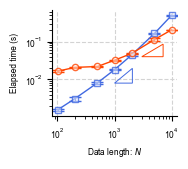

In [75]:
fig, ax = plt.subplots(1, 1, figsize=(45 * MM, 40 * MM))
dt_array = jnp.asarray(dt_list)
length_array = jnp.asarray([len(jnp.arange(0.0, 1.0 + dt, dt)) for dt in dt_array])
for (name, y_mean), y_std in zip(t_mean_dict.items(), t_std_dict.values()):
    ax = connected_scatter(
        ax,
        length_array,
        y_mean,
        y_std,
        label=name,
        capsize=4.0,
        **connected_scatter_kwargs[name]
    )

ax.set_xscale("log", base=10)
ax.set_yscale("log", base=10)

ax.set_xlabel(r"Data length: $N$")
ax.set_ylabel("Elapsed time (s)")

ax = draw_triangle(
    ax,
    (1000, 0.008),
    slope=1.25,
    hypotenuse=0.5,
    facecolor="none",
    edgecolor="royalblue",
    linewidth=0.7,
)
ax = draw_triangle(
    ax,
    (3000, 0.04),
    slope=0.89,
    hypotenuse=0.5,
    facecolor="none",
    edgecolor="orangered",
    linewidth=0.7,
)
ax.set_axisbelow(True)
fig.savefig("../figures/fig2-d.pdf", format="pdf", dpi=1200)

In [25]:
from scipy.stats import linregress

res = linregress(
    jnp.log10(length_array),
    jnp.log10(jnp.asarray(t_mean_dict["Viscoindent"])),
)
res.slope
# t_mean_dict["ForceIndent-JAX"]

1.2466432707796986

In [73]:
sel = slice(0, -4)
res = linregress(
    jnp.log10(length_array)[sel],
    jnp.log10(jnp.asarray(t_mean_dict["ForceIndent-JAX"])[sel]),
)
res.slope

0.8949670729256415

In [43]:
cpu_device = jax.devices("cpu")[0]
with jax.default_device(cpu_device):
    tip = Spherical(r=1.0)
    indentation = (
        IndentationBuilder()
        .append(ConstantVelocity(velocity_=2.0), duration=0.5)
        .append(ConstantVelocity(velocity_=-2.0), duration=0.5)
        .build()
    )
    powerlaw = PowerLaw(E0=3.0, alpha=0.2)

    dt_list = [1e-4, 2e-4, 5e-4, 1e-3, 2e-3, 5e-3, 1e-2]
    t_mean_dict = {"ForceIndent-JAX": [], "Viscoindent": []}
    t_std_dict = {"ForceIndent-JAX": [], "Viscoindent": []}

    force_ting_jit = eqx.filter_jit(force_ting)
    for dt in tqdm(dt_list):
        t = jnp.arange(0.0, 1.0 + dt, dt)
        (
            t_mean,
            t_std,
        ) = time_forceindentjax(t, powerlaw, indentation, tip)
        t_mean_dict["ForceIndent-JAX"].append(t_mean)
        t_std_dict["ForceIndent-JAX"].append(t_std)

        (
            t_mean2,
            t_std2,
        ) = time_viscoindent(t, powerlaw, indentation, tip)
        t_mean_dict["Viscoindent"].append(t_mean2)
        t_std_dict["Viscoindent"].append(t_std2)

100%|██████████| 7/7 [01:13<00:00, 10.45s/it]


Text(0, 0.5, 'Elapsed time')

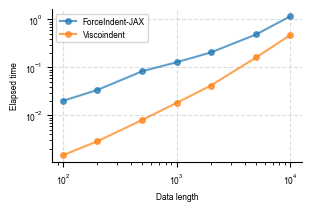

In [44]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2))
dt_array = jnp.asarray(dt_list)
length_array = jnp.asarray([len(jnp.arange(0.0, 1.0 + dt, dt)) for dt in dt_array])
for k, v in t_mean_dict.items():
    ax.plot(length_array, jnp.asarray(v), ".-", markersize=8.0, label=k, alpha=0.7)
    ax.set_xscale("log", base=10)
    ax.set_yscale("log", base=10)
ax.legend()
ax.set_xlabel(r"Data length")
ax.set_ylabel("Elapsed time")